In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.io import loadmat
from scipy.linalg import svd
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.family'] = 'Arial'

In [3]:
df = pd.read_csv('data/behavior_data/behavior_data.csv')
df.head()

,trialNum,firstVal,secondVal,firstIsChosen,decisionRT,firstFixLat,secondFixLat,thirdFixLat,session,monkey_id,chosenVal
0,6,1,3,0,0.827066,0.162,0.510,NaN,1,0,3.0
1,11,1,2,1,0.847049,0.164,0.372,0.616,1,0,1.0
2,18,1,5,0,0.897351,0.166,0.414,NaN,1,0,5.0
3,61,1,1,0,0.877376,0.163,0.415,NaN,1,0,1.0
4,62,1,5,0,0.937264,0.178,0.430,NaN,1,0,5.0


In [4]:
with open('data/neural_data/neural_data.p', 'rb') as f:
    spikes = pickle.load(f)

print(len(spikes)) # (n_sessions)
print(spikes[0].shape) # (n_trials, n_timesteps, n_cells, 3)

32
(587, 70, 22, 3)


In [5]:
bin_edges = loadmat('data/mcginty_and_lupkin_data_for_mattar_lab.mat')['metaData'][0][0][1]
bin_edges = np.round(bin_edges, 3)
bin_edges

array([[-0.2 , -0.19],
       [-0.19, -0.18],
       [-0.18, -0.17],
       [-0.17, -0.16],
       [-0.16, -0.15],
       [-0.15, -0.14],
       [-0.14, -0.13],
       [-0.13, -0.12],
       [-0.12, -0.11],
       [-0.11, -0.1 ],
       [-0.1 , -0.09],
       [-0.09, -0.08],
       [-0.08, -0.07],
       [-0.07, -0.06],
       [-0.06, -0.05],
       [-0.05, -0.04],
       [-0.04, -0.03],
       [-0.03, -0.02],
       [-0.02, -0.01],
       [-0.01, -0.  ],
       [ 0.  ,  0.01],
       [ 0.01,  0.02],
       [ 0.02,  0.03],
       [ 0.03,  0.04],
       [ 0.04,  0.05],
       [ 0.05,  0.06],
       [ 0.06,  0.07],
       [ 0.07,  0.08],
       [ 0.08,  0.09],
       [ 0.09,  0.1 ],
       [ 0.1 ,  0.11],
       [ 0.11,  0.12],
       [ 0.12,  0.13],
       [ 0.13,  0.14],
       [ 0.14,  0.15],
       [ 0.15,  0.16],
       [ 0.16,  0.17],
       [ 0.17,  0.18],
       [ 0.18,  0.19],
       [ 0.19,  0.2 ],
       [ 0.2 ,  0.21],
       [ 0.21,  0.22],
       [ 0.22,  0.23],
       [ 0.

In [6]:
from scipy.linalg import svd
from sklearn.linear_model import LassoCV


def stratified_train_test_split(df_session, test_size = 0.3, random_state = 42):
    """
    Stratified split ensuring balanced distribution of trial types.
    Stratify by first and second offer values.
    """

    np.random.seed(random_state)
    
    # create stratification key
    strat_key = df_session['firstVal'].astype(str) + '_' + df_session['secondVal'].astype(str)
    unique_strats = strat_key.unique()
    
    train_indices = []
    test_indices = []
    
    for strat in unique_strats:
        strat_indices = np.where(strat_key == strat)[0]
        n_test = max(1, int(len(strat_indices) * test_size))
        
        # shuffle and split
        shuffled = np.random.permutation(strat_indices)
        test_indices.extend(shuffled[:n_test])
        train_indices.extend(shuffled[n_test:])
    
    return np.array(train_indices), np.array(test_indices)


def fit_lasso_decoder(X_train, y_train):
    """
    Fit LASSO model with 10-fold cross-validation to select lambda.
    Returns fitted model.
    """

    # use LassoCV for automatic lambda selection via cross-validation
    # alphas: regularization strengths to try (lambda in the paper)
    alphas = np.logspace(-3, 1, 100)
    
    lasso_cv = LassoCV(
        alphas = alphas,
        cv = 10, # 10-fold cross-validation as specified in paper
        max_iter = 10000,
        random_state = 42,
        n_jobs = -1
    )
    
    lasso_cv.fit(X_train, y_train)
    
    return lasso_cv


def compute_value_weights_for_session(X_train, y1_train, y2_train):
    """
    Compute beta1 and beta2 (LASSO weights) for a single session.
    
    Returns:
        beta1, beta2: weight vectors
    """

    # fit LASSO for 1st value
    lasso1 = fit_lasso_decoder(X_train, y1_train)
    beta1 = lasso1.coef_
    
    # fit LASSO for 2nd value
    lasso2 = fit_lasso_decoder(X_train, y2_train)
    beta2 = lasso2.coef_
    
    return beta1, beta2


def find_value_subspace_basis(beta1, beta2, X):
    """
    Find orthonormal basis for value subspace using Semedo et al. method.
    
    Parameters:
        beta1: weights from LASSO model for 1st value (n_cells,)
        beta2: weights from LASSO model for 2nd value (n_cells,)
        X: spike count matrix (n_trials, n_cells)
    
    Returns:
        Q: orthonormal basis for value subspace (n_cells, 2)
    """
    
    # concatenate weight vectors into n x 2 matrix B
    B = np.column_stack([beta1, beta2]) # (n_cells, 2)
    
    # compute covariance matrix of spike data
    cov_X = np.cov(X.T)
    
    # compute M = B^T × cov(X)
    M = B.T @ cov_X
    
    # SVD of M
    U, D, Vt = svd(M, full_matrices=False)
    V = Vt.T
    
    # take first 2 columns of V (corresponding to non-zero singular values)
    Q = V[:, :2] # (n_cells, 2)
    
    return Q

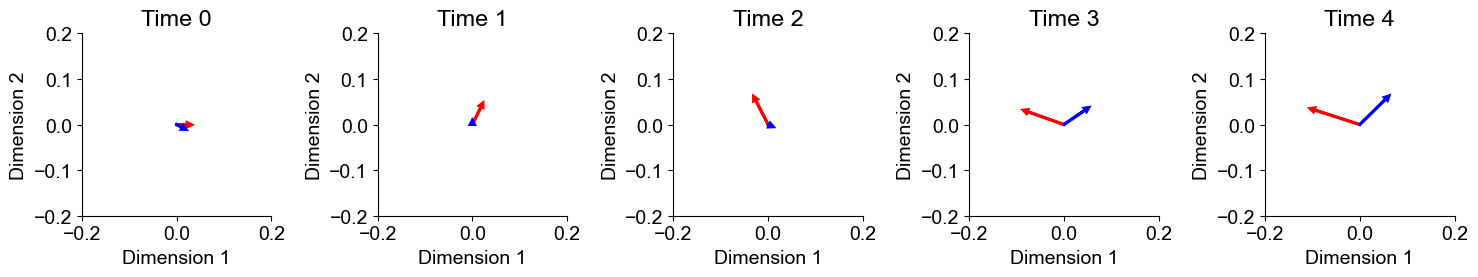

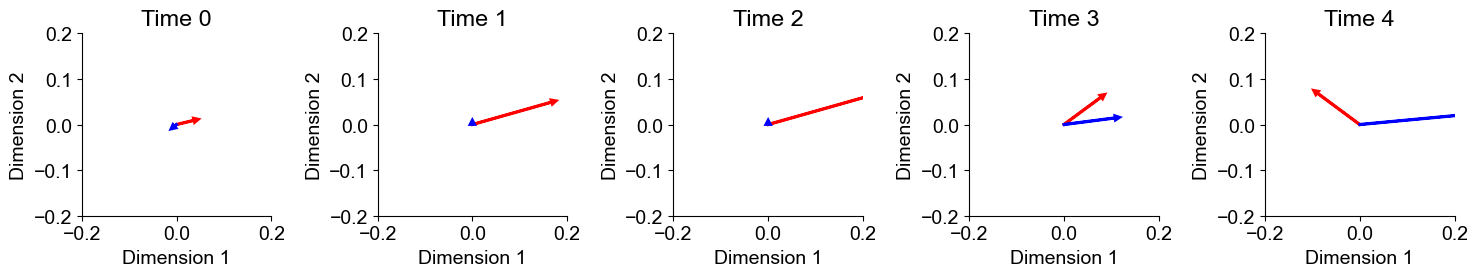

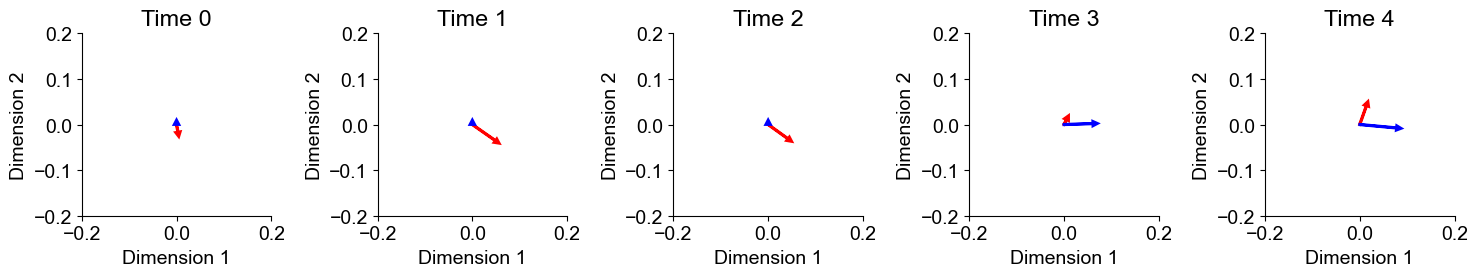

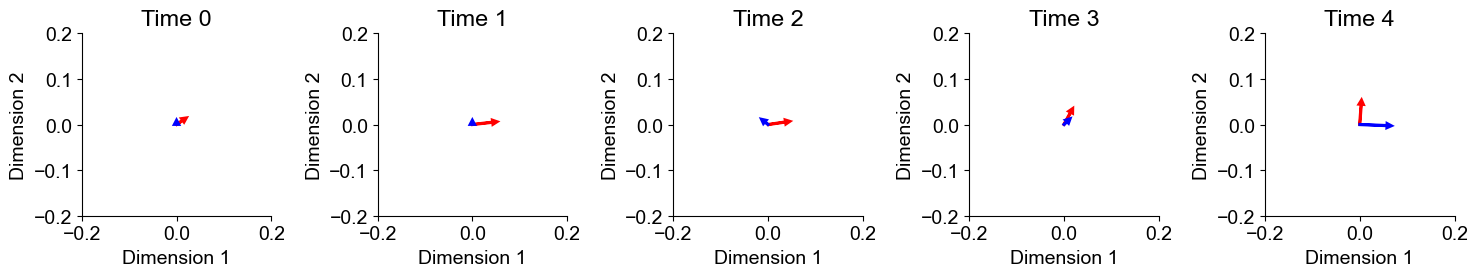

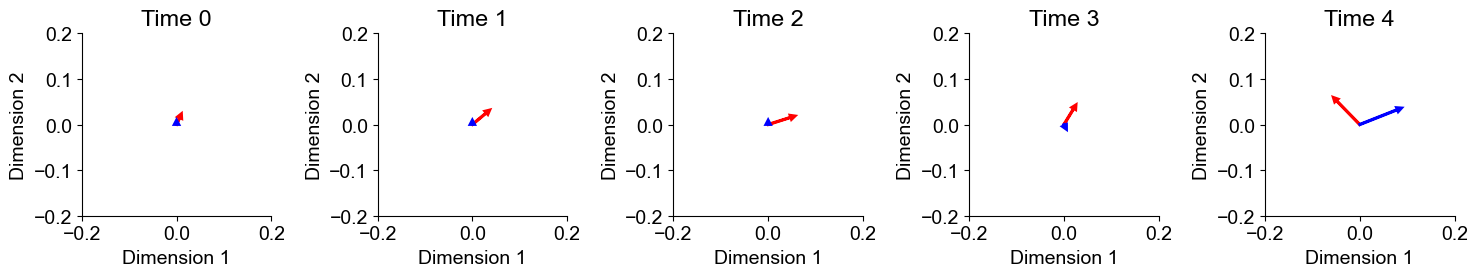

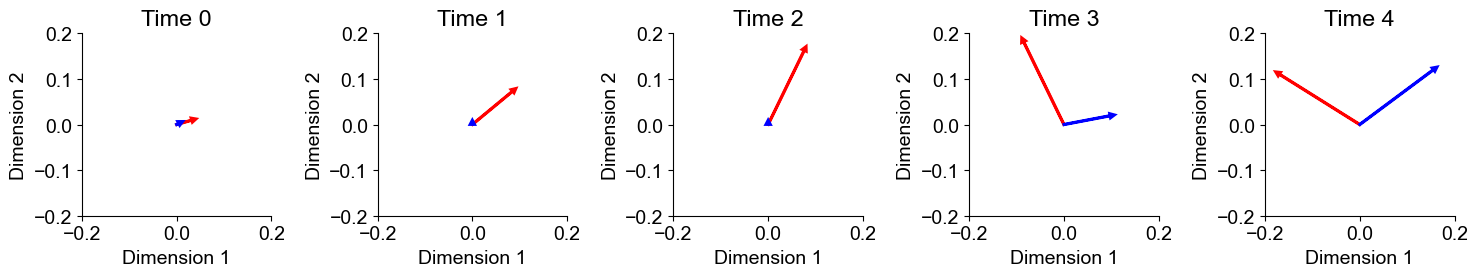

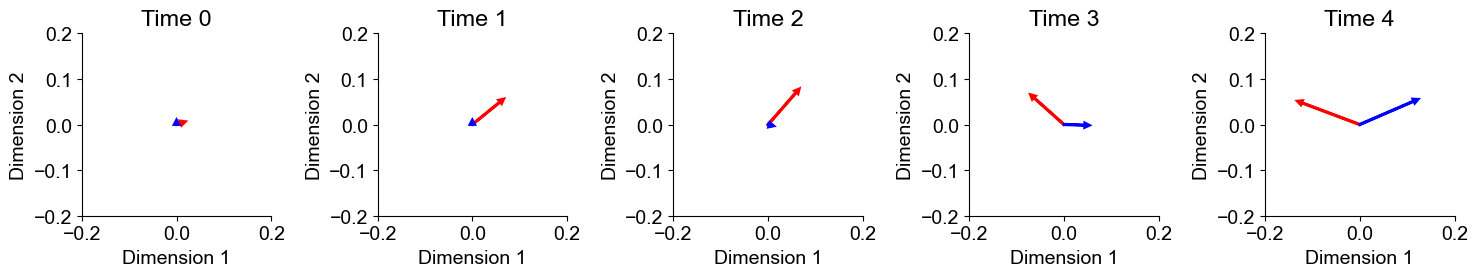

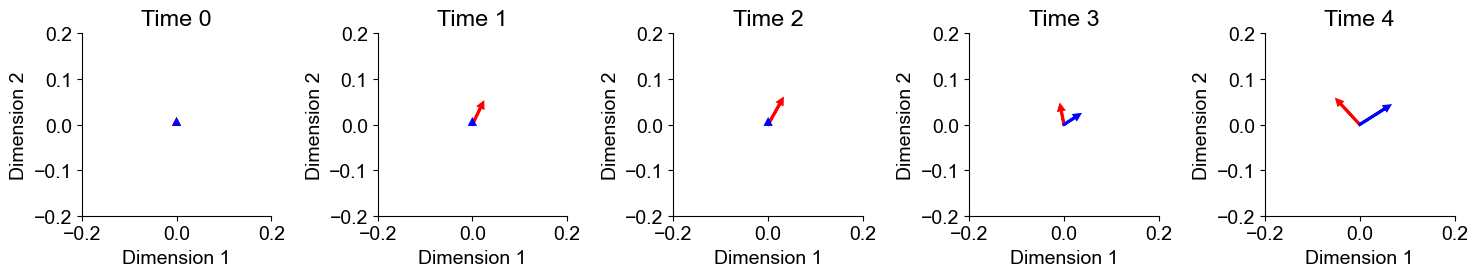

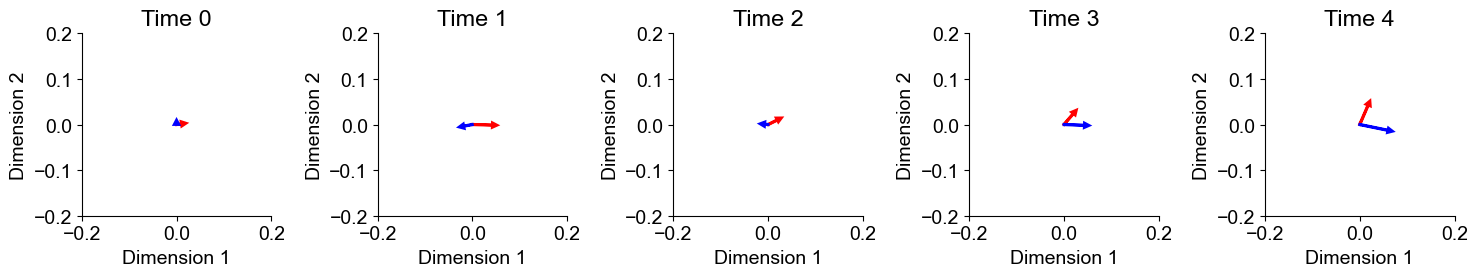

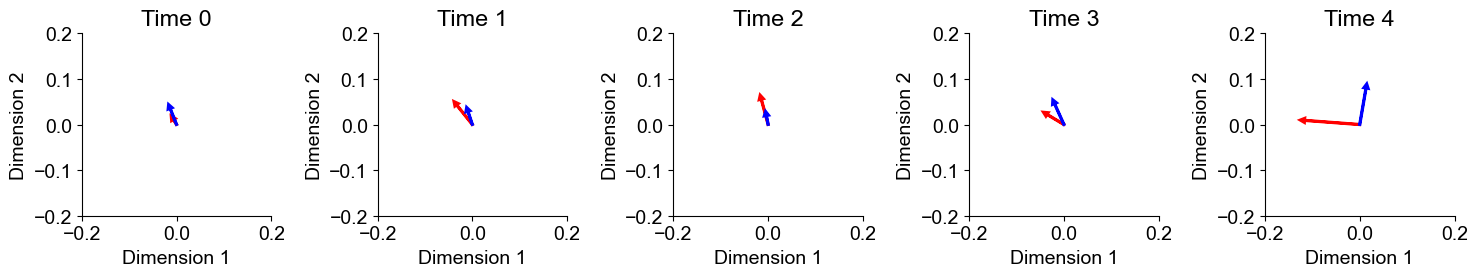

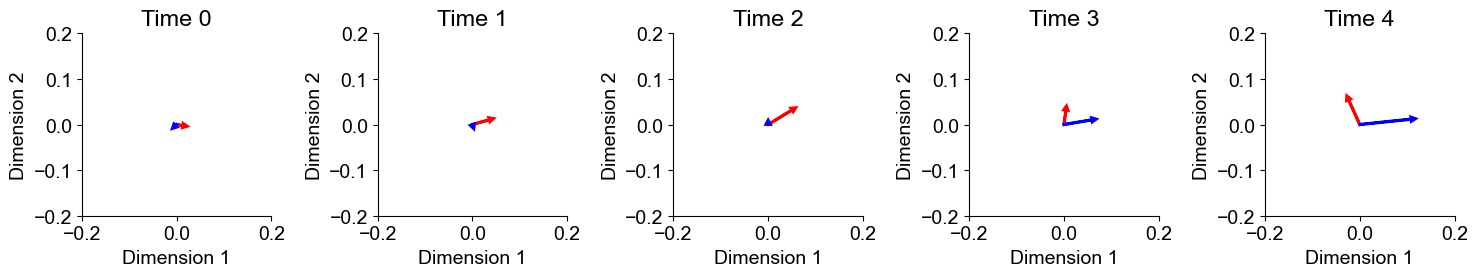

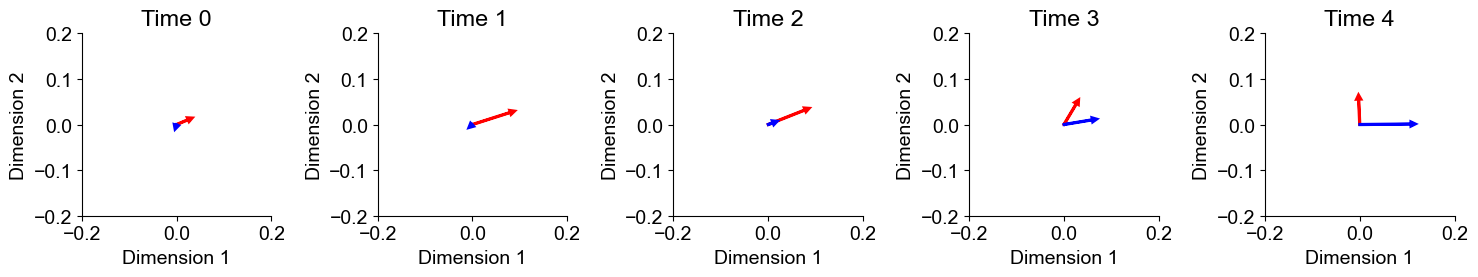

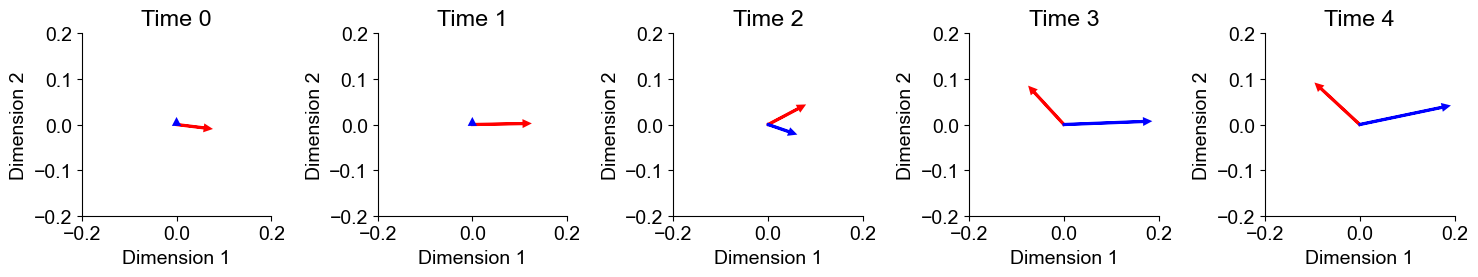

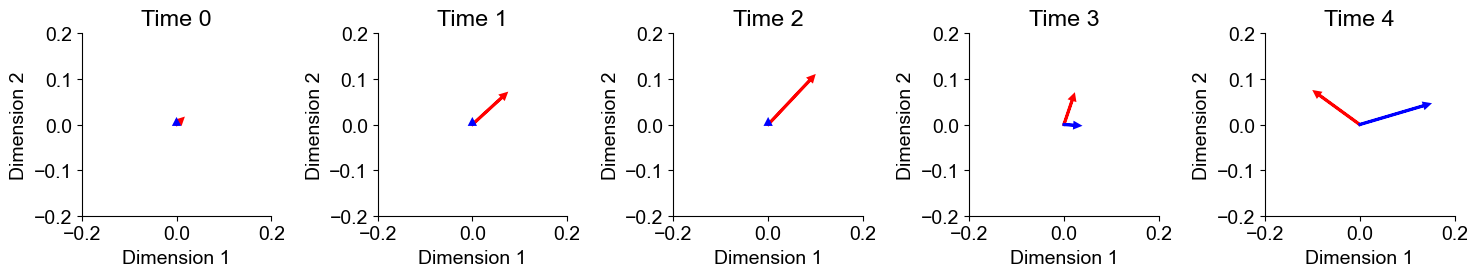

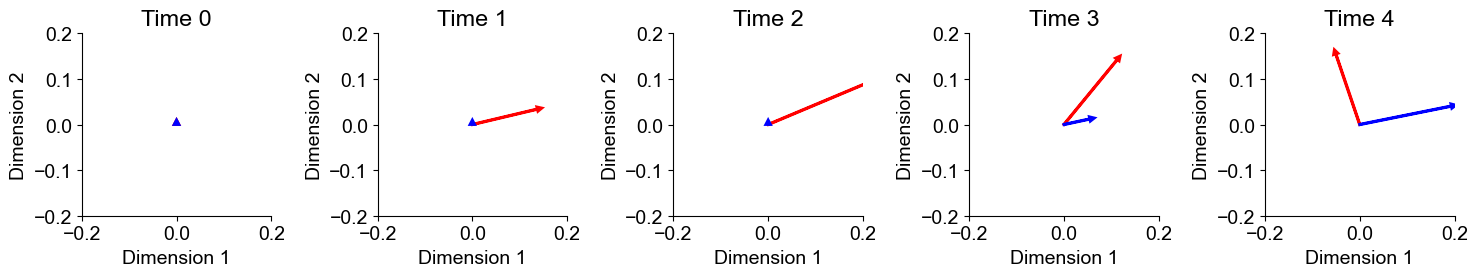

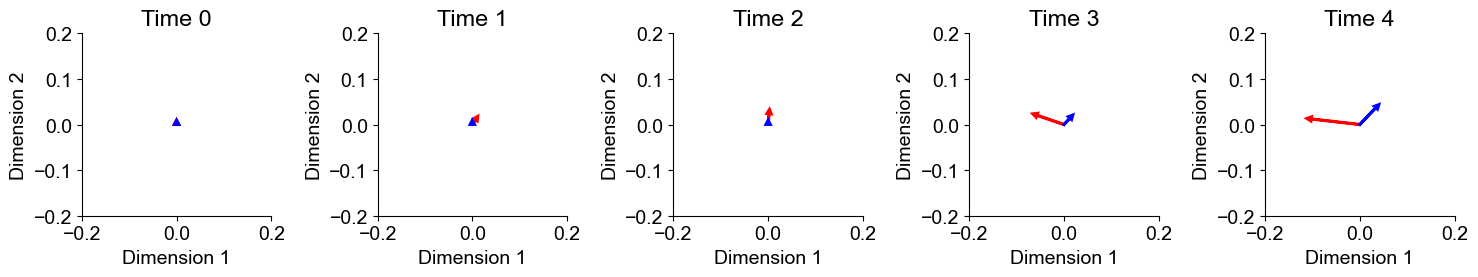

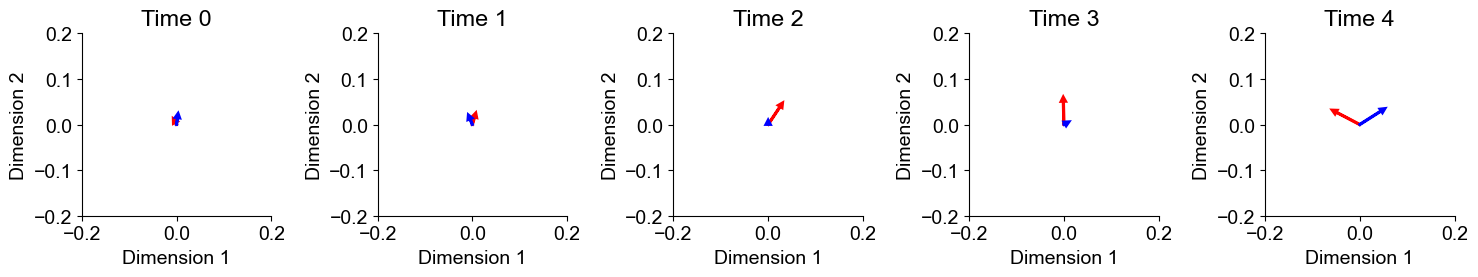

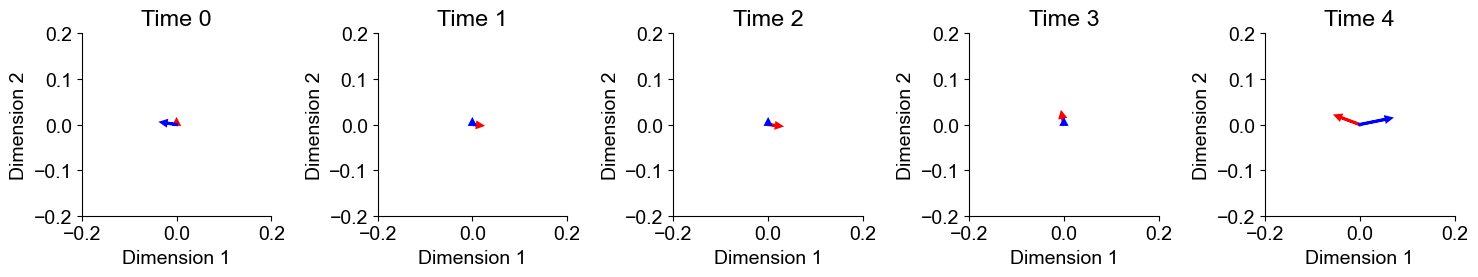

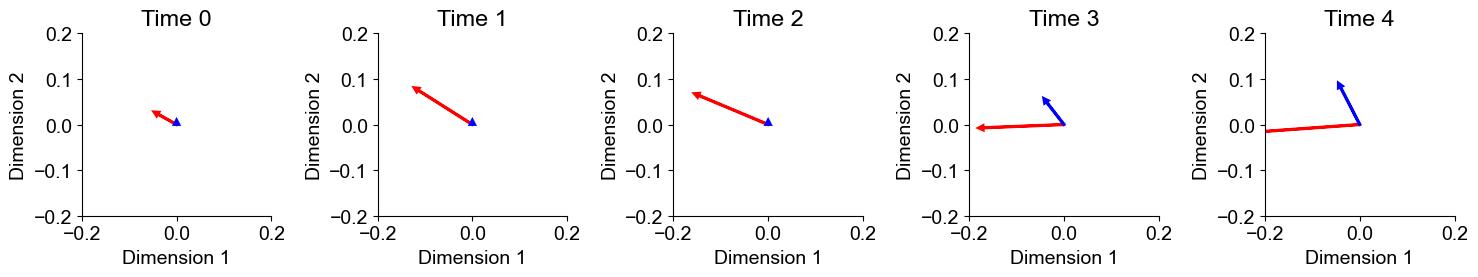

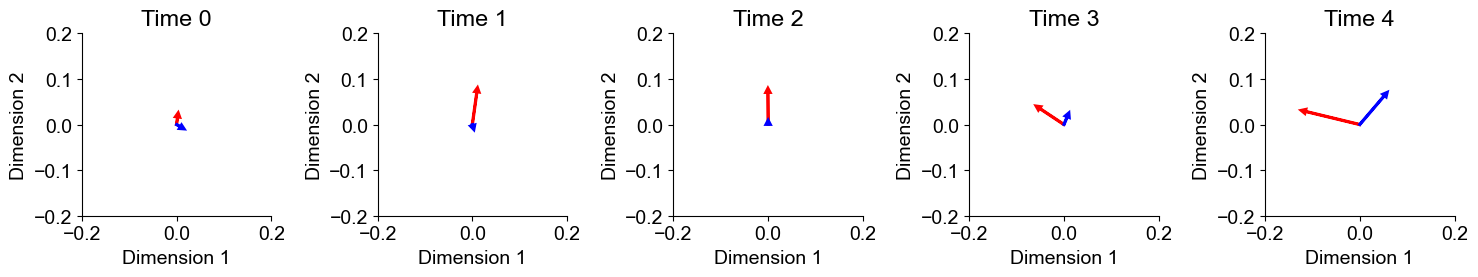

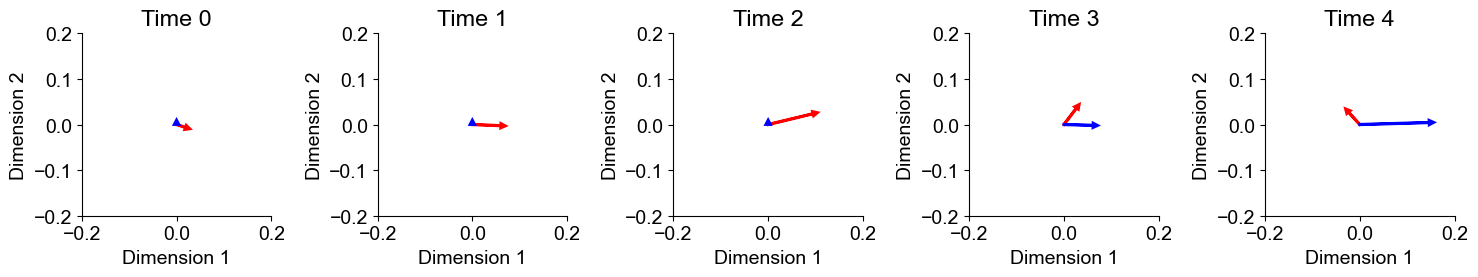

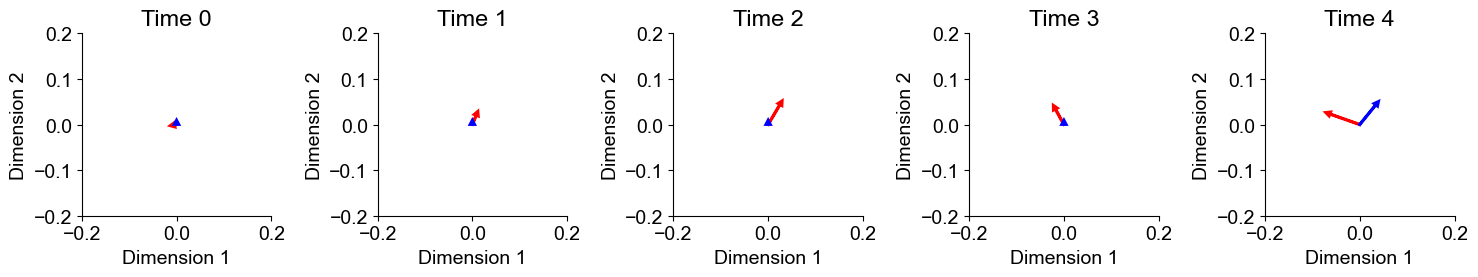

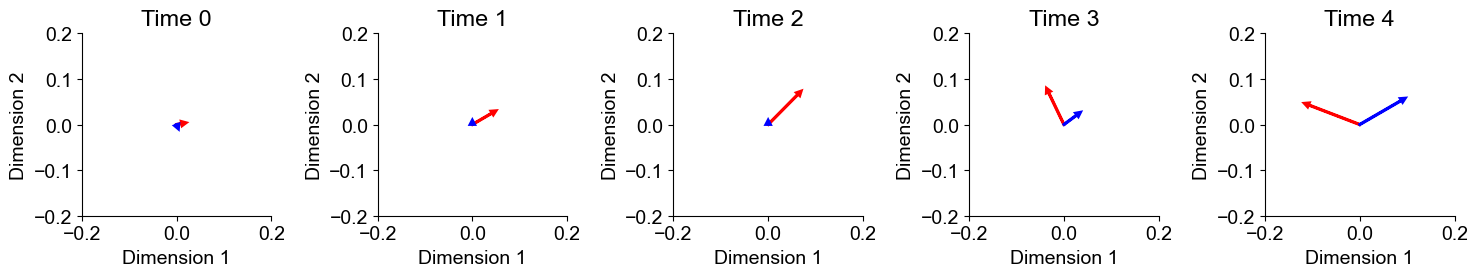

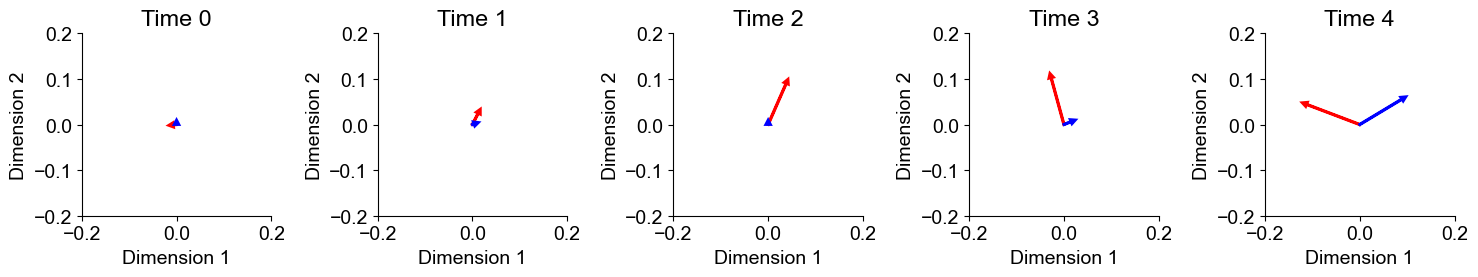

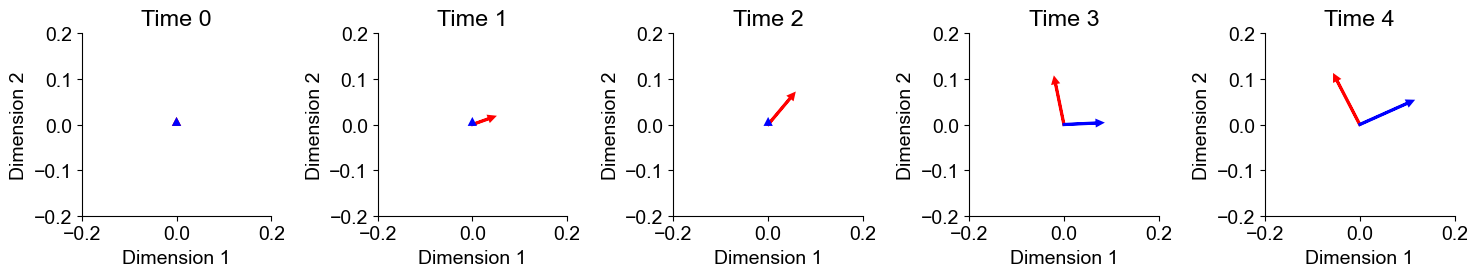

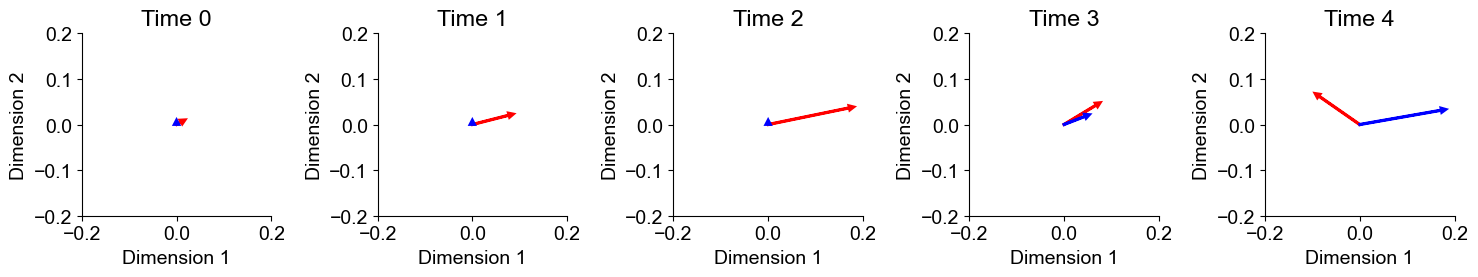

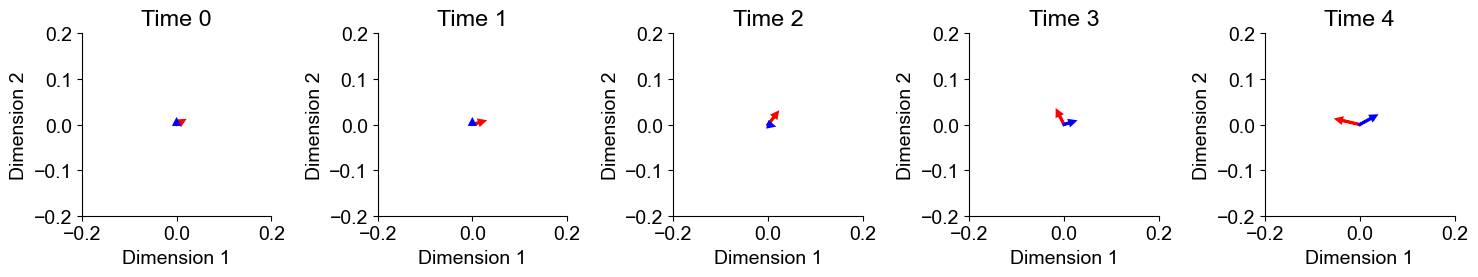

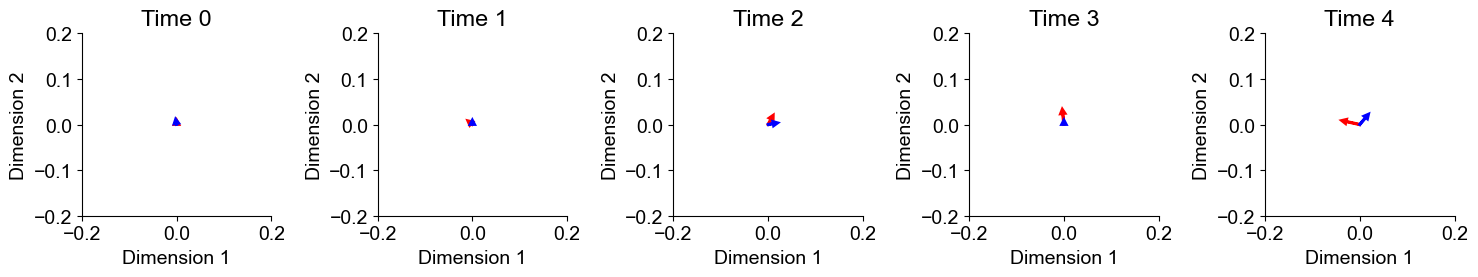

In [7]:
enc1_projections = []
enc2_projections = []

# use the "late" epoch: 0.2-0.4s after second target viewing
start_idx = 40
end_idx = 59

for i_session in range(0, 32):

    if i_session in [11, 19, 29, 30]:  # skip failed sessions
        continue

    # get session data
    session_idx = i_session
    df_session = df[df['session'] == session_idx + 1]
    spikes_session = spikes[session_idx]

    # stratified train-test split
    train_idx, test_idx = stratified_train_test_split(
        df_session = df_session,
        test_size = 0.3
    )

    first_val = df_session['firstVal'].values
    second_val = df_session['secondVal'].values

    # average spike counts over the epoch
    alignment = 1
    X = spikes_session[:, start_idx: end_idx, :, alignment].mean(axis = 1)

    # make datasets
    X_train, X_test = X[train_idx], X[test_idx]
    y1_train, y1_test = first_val[train_idx], first_val[test_idx]
    y2_train, y2_test = second_val[train_idx], second_val[test_idx]

    # compute betas
    beta1, beta2 = compute_value_weights_for_session(
        X_train, y1_train, y2_train
    )

    # find value subspace basis using Semedo method
    Q = find_value_subspace_basis(beta1, beta2, X_train)

    # project test data into value subspace
    X_projected = X_test @ Q  # (n_test_trials, 2)


    enc1_projections_session = []
    enc2_projections_session = []

    fig, axes = plt.subplots(1, 5, figsize = (15, 3))

    for t, start_idx in enumerate(np.arange(0, 50, 10)):
        end_idx = start_idx + 19
        
        # average spike counts over the epoch
        alignment = 1
        X = spikes_session[:, start_idx: end_idx, :, alignment].mean(axis = 1)

        # make datasets
        X_train, X_test = X[train_idx], X[test_idx]
        y1_train, y1_test = first_val[train_idx], first_val[test_idx]
        y2_train, y2_test = second_val[train_idx], second_val[test_idx]

        # compute betas
        beta1_t, beta2_t = compute_value_weights_for_session(
            X_train, y1_train, y2_train
        )

        # covariance-weighted ("encoding") directions
        # cov across units (H,H)
        cov_X_t = np.cov(X_train.T)

        enc1_t = cov_X_t @ beta1_t   # (H,)
        enc2_t = cov_X_t @ beta2_t   # (H,)

        # project encoding directions into the (fixed) value subspace Q
        enc1_t_proj = enc1_t @ Q # (2,)
        enc2_t_proj = enc2_t @ Q # (2,)

        enc1_projections_session.append(enc1_t_proj)
        enc2_projections_session.append(enc2_t_proj)


        ax = axes[t]

        ax.arrow(0, 0, enc1_t_proj[0], enc1_t_proj[1], head_width = 0.01, head_length = 0.01, fc = 'red', ec = 'red', linewidth = 2, label = 'beta1 (1st value weights)')
        ax.arrow(0, 0, enc2_t_proj[0], enc2_t_proj[1], head_width = 0.01, head_length = 0.01, fc = 'blue', ec = 'blue', linewidth = 2, label = 'beta2 (2nd value weights)')
                            
        ax.set_xlim(-0.2, 0.2)
        ax.set_ylim(-0.2, 0.2)
                                    
        ax.set_xlabel('Dimension 1')
        ax.set_ylabel('Dimension 2')
        ax.set_title(f'Time {t}')
        
    enc1_projections.append(np.array(enc1_projections_session))
    enc2_projections.append(np.array(enc2_projections_session))

    plt.tight_layout()
    plt.show()


enc1_projections = np.array(enc1_projections)
enc2_projections = np.array(enc2_projections)

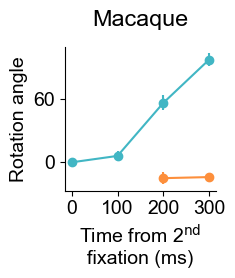

In [8]:
enc1_projections_normalized = enc1_projections / np.linalg.norm(enc1_projections, axis = -1, keepdims = True)
angles1 = np.degrees(np.arctan2(enc1_projections_normalized[:, :, 1], enc1_projections_normalized[:, :, 0]))

enc2_projections_normalized = enc2_projections / np.linalg.norm(enc2_projections, axis = -1, keepdims = True)
angles2 = np.degrees(np.arctan2(enc2_projections_normalized[:, :, 1], enc2_projections_normalized[:, :, 0]))

# fix the period issue
angles1 = np.where(angles1 < -120, angles1 + 360, angles1)
baseline = angles1[:, 1][:, np.newaxis].copy()
angles1 -= baseline
angles2 -= baseline


colors = ['#41b6c4', '#fd8f3c']
plt.figure(figsize = (2.55, 3))

means = np.nanmean(angles1, axis = 0)
errors = np.nanstd(angles1, axis = 0, ddof = 1) / np.sqrt(np.sum(~np.isnan(angles1), axis = 0))
plt.errorbar([0, 0.1, 0.2, 0.3], means[1:], yerr = errors[1:], fmt = 'o-', color = colors[0])

means = np.nanmean(angles2, axis = 0)
errors = np.nanstd(angles2, axis = 0, ddof = 1) / np.sqrt(np.sum(~np.isnan(angles2), axis = 0))
plt.errorbar([0.2, 0.3], means[3:], yerr = errors[3:], fmt = 'o-', color = colors[1])

# plt.axhline(y = angles2[:, -1].mean())
plt.xticks([0, 0.1, 0.2, 0.3], labels = [0, 100, 200, 300])
plt.yticks([0, 60])
plt.ylabel(r'Rotation angle')
plt.xlabel(r'Time from 2$^\text{nd}$' + '\nfixation (ms)')
plt.title('Macaque', pad = 15)
plt.tight_layout()
plt.savefig('figures/p_angle.pdf', bbox_inches = 'tight')

=== Analyzing Session 1 ===
[0.   0.05] [0.   0.05]
[0.08473939 0.07286207] [0.   0.05]
[0.07606647 0.16240363] [0.   0.05]
[-0.08503786  0.18137412] [0.09726818 0.01921667]
[-0.16945563  0.11026874] [0.15547863 0.12018153]


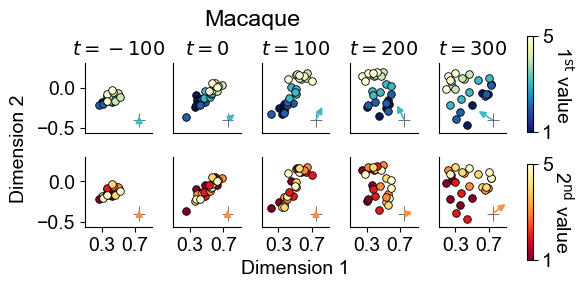

In [9]:
# use the "late" epoch: 0.2-0.4s after second target viewing
start_idx = 40
end_idx = 59

# analyze first session as an example
print('=== Analyzing Session 1 ===')
session_idx = 5
df_session = df[df['session'] == session_idx + 1]
spikes_session = spikes[session_idx]

# stratified train-test split
train_idx, test_idx = stratified_train_test_split(
    df_session = df_session,
    test_size = 0.3
)

first_val = df_session['firstVal'].values
second_val = df_session['secondVal'].values

# average spike counts over the epoch
alignment = 1
X = spikes_session[:, start_idx: end_idx, :, alignment].mean(axis = 1) # (n_trials, n_cells)

# make datasets
X_train, X_test = X[train_idx], X[test_idx]
y1_train, y1_test = first_val[train_idx], first_val[test_idx]
y2_train, y2_test = second_val[train_idx], second_val[test_idx]

# compute betas
beta1, beta2 = compute_value_weights_for_session(
    X_train, y1_train, y2_train
)

# find value subspace basis using Semedo method
Q = find_value_subspace_basis(beta1, beta2, X_train)

# project test data into value subspace
X_projected = X_test @ Q  # (n_test_trials, 2)


fig, axes = plt.subplots(2, 5, figsize = (5.5, 3.2))

for t, start_idx in enumerate(np.arange(0, 50, 10)):
    end_idx = start_idx + 19
    
    # average spike counts over the epoch
    alignment = 1
    X = spikes_session[:, start_idx: end_idx, :, alignment].mean(axis = 1)

    # make datasets
    X_train, X_test = X[train_idx], X[test_idx]
    y1_train, y1_test = first_val[train_idx], first_val[test_idx]
    y2_train, y2_test = second_val[train_idx], second_val[test_idx]

    # project test data into value subspace
    X_projected = X_test @ Q  # (n_test_trials, 2)

    for i in range(2):
        ax = axes[i, t]

        for v1 in [1, 2, 3, 4, 5]:
            for v2 in [1, 2, 3, 4, 5]:
                mask = (y1_test == v1) & (y2_test == v2)
                if np.sum(mask) > 0:
                    mean_pos = X_projected[mask].mean(axis=0)
                    if i == 0:
                        sc1 = ax.scatter(mean_pos[0], mean_pos[1], s = 30, c = v1, vmin = 1, vmax = 5, cmap = 'YlGnBu_r', marker = 'o', edgecolors = 'k', linewidth = 0.6)
                    else:
                        sc2 = ax.scatter(mean_pos[0], mean_pos[1], s = 30, c = v2, vmin = 1, vmax = 5, cmap = 'YlOrRd_r', marker = 'o', edgecolors = 'k', linewidth = 0.6)

        # ax.set_xlim(-0.2, 0.35)
        # ax.set_ylim(-0.25, 0.3)
        ax.set_xlim(0.1, 0.91)
        ax.set_ylim(-0.56, 0.3)

        if t != 0:
            ax.set_yticks([])
        if i == 0:
            ax.set_xticks([])
        else:
            ax.set_xticks([0.3, 0.7])
        
        if i == 1 and t == 2:
            ax.set_xlabel('Dimension 1')
        # ax.set_ylabel('Dimension 2')

        if i == 0:
            ax.set_title(rf'$t = {t * 100 - 100}$', fontsize = 14)


colors = ['#41b6c4', '#fd8f3c']

scale_factor = 1 / 1
threshold = 0.04
center_x = 0.75
center_y = -0.4
delta_x = 0.07
delta_y = 0.09

for t, start_idx in enumerate(np.arange(0, 50, 10)):
    end_idx = start_idx + 19
    
    # average spike counts over the epoch
    alignment = 1
    X = spikes_session[:, start_idx: end_idx, :, alignment].mean(axis = 1)

    # make datasets
    X_train, X_test = X[train_idx], X[test_idx]
    y1_train, y1_test = first_val[train_idx], first_val[test_idx]
    y2_train, y2_test = second_val[train_idx], second_val[test_idx]

    # compute betas
    beta1_t, beta2_t = compute_value_weights_for_session(
        X_train, y1_train, y2_train
    )

    # covariance-weighted ("encoding") directions
    # cov across units (H,H)
    cov_X_t = np.cov(X_train.T)

    enc1_t = cov_X_t @ beta1_t   # (H,)
    enc2_t = cov_X_t @ beta2_t   # (H,)

    # project encoding directions into the (fixed) value subspace Q
    enc1_t_proj = enc1_t @ Q * scale_factor   # (2,)
    enc2_t_proj = enc2_t @ Q * scale_factor   # (2,)


    ax = axes[0, t]
    if np.linalg.norm(enc1_t_proj) < threshold:
        enc1_t_proj = np.array([0, 5e-2])
    ax.annotate(
        "",
        xy = (center_x + enc1_t_proj[0], center_y + enc1_t_proj[1]),
        xytext = (center_x, center_y),
        arrowprops = dict(
            arrowstyle = '-|>',
            color = colors[0],
            linewidth = 1.2,
            shrinkA = 0,
            shrinkB = 0,
            mutation_scale = 10
        )
    )
    ax.hlines(y = center_y, xmin = center_x - delta_x, xmax = center_x + delta_x, color = 'k', linewidth = 0.5, alpha = 0.8)
    ax.vlines(x = center_x, ymin = center_y - delta_y, ymax = center_y + delta_y, color = 'k', linewidth = 0.5, alpha = 0.8)

    ax = axes[1, t]
    if np.linalg.norm(enc2_t_proj) < threshold:
        enc2_t_proj = np.array([0, 5e-2])
    ax.annotate(
        "",
        xy = (center_x + enc2_t_proj[0], center_y + enc2_t_proj[1]),
        xytext = (center_x, center_y),
        arrowprops = dict(
            arrowstyle = '-|>',
            color = colors[1],
            linewidth = 1.2,
            shrinkA = 0,
            shrinkB = 0,
            mutation_scale = 10
        )
    )
    ax.hlines(y = center_y, xmin = center_x - delta_x, xmax = center_x + delta_x, color = 'k', linewidth = 0.5, alpha = 0.8)
    ax.vlines(x = center_x, ymin = center_y - delta_y, ymax = center_y + delta_y, color = 'k', linewidth = 0.5, alpha = 0.8)

    print(enc1_t_proj, enc2_t_proj)


fig.supylabel('Dimension 2', x = 0.06, y = 0.6, fontsize = 14)
fig.supxlabel('Macaque', x = 0.5, y = 0.97, fontsize = 16.8)


cbar_ax1 = fig.add_axes([1, 0.65, 0.01, 0.3])  # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([1, 0.25, 0.01, 0.3])

# # Create the colorbars
cbar1 = fig.colorbar(sc1, cax = cbar_ax1)
cbar2 = fig.colorbar(sc2, cax = cbar_ax2)

cbar1.set_ticks([1, 5])  # Adjust values based on your data range
cbar2.set_ticks([1, 5])  # Example for different range

# # Customize labels (rotation, position, spacing)
cbar1.set_label(r'1$^\text{st}$ value', rotation = 270, labelpad = 15)
cbar2.set_label(r'2$^\text{nd}$ value', rotation = 270, labelpad = 15)

plt.tight_layout()
# plt.show()
plt.savefig('figures/p_time_course.pdf', bbox_inches = 'tight')